# Speech Emotion Recognition on RAVDESS

Walkthrough of the pipeline in `src/`. This notebook **reads the artefacts the
pipeline produced** rather than recomputing them, so nothing here can disagree
with `report.md`.

Run `python src/run_all.py` first if `outputs/` is empty.

In [1]:
import json, sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import config as C

FIG = ROOT / "outputs" / "figures"
MET = ROOT / "outputs" / "metrics"
print("project root:", ROOT)

project root: C:\Emotion detection\-Emotion-Recognition-from-Speech


## 1. Dataset

RAVDESS speech subset. Labels are encoded in the filename, e.g.
`03-01-06-01-02-01-12.wav` = audio-only / speech / fearful / strong /
statement 2 / repetition 1 / actor 12.

In [2]:
summary = json.loads((MET / "dataset_summary.json").read_text())
for k in ["total_recordings", "total_speakers", "total_emotions",
          "corrupt_or_unreadable", "missing_files", "duplicate_md5_files",
          "sampling_rates", "channels", "imbalance_ratio_max_over_min"]:
    print(f"{k:32s} {summary[k]}")
print()
print("duration (s):", {k: round(v, 3) for k, v in summary["duration_sec"].items()})
print("class distribution:", summary["class_distribution"])

total_recordings                 1440
total_speakers                   24
total_emotions                   8
corrupt_or_unreadable            0
missing_files                    0
duplicate_md5_files              2
sampling_rates                   {'48000': 1440}
channels                         {'1': 1435, '2': 5}
imbalance_ratio_max_over_min     2.0

duration (s): {'min': 2.936, 'max': 5.272, 'mean': 3.701, 'median': 3.67, 'std': 0.337}
class distribution: {'neutral': 96, 'calm': 192, 'happy': 192, 'sad': 192, 'angry': 192, 'fearful': 192, 'disgust': 192, 'surprised': 192}


In [3]:
manifest = pd.read_csv(ROOT / "data" / "processed" / "manifest.csv")
manifest.head()

,path,filename,modality,vocal_channel,emotion_code,emotion,intensity,statement,repetition,actor,gender,split,error,duration,sr,channels,frames,subtype,md5
0,C:\Emotion detection\-Emotion-Recognition-from...,03-01-01-01-01-01-01.wav,3,1,1,neutral,normal,Kids are talking by the door,1,1,male,train,NaN,3.303292,48000,1,158558,PCM_16,880ae6a06b809441b366a04d94cc6526
1,C:\Emotion detection\-Emotion-Recognition-from...,03-01-01-01-01-02-01.wav,3,1,1,neutral,normal,Kids are talking by the door,2,1,male,train,NaN,3.336667,48000,1,160160,PCM_16,89c4c44b112dd9f92b0fbfd196993ae5
2,C:\Emotion detection\-Emotion-Recognition-from...,03-01-01-01-02-01-01.wav,3,1,1,neutral,normal,Dogs are sitting by the door,1,1,male,train,NaN,3.269917,48000,1,156956,PCM_16,c42dc571fee813208a5d291aed771878
3,C:\Emotion detection\-Emotion-Recognition-from...,03-01-01-01-02-02-01.wav,3,1,1,neutral,normal,Dogs are sitting by the door,2,1,male,train,NaN,3.169833,48000,1,152152,PCM_16,a9feefc64ca15ee755b0116e16edef94
4,C:\Emotion detection\-Emotion-Recognition-from...,03-01-02-01-01-01-01.wav,3,1,2,calm,normal,Kids are talking by the door,1,1,male,train,NaN,3.536854,48000,1,169769,PCM_16,bb245edb08569d3bc983daad540f11b1


### Class balance and clip durations

Only `neutral` is under-represented (96 vs 192): RAVDESS records neutral at
normal intensity only. That 2:1 ratio is handled with class weights, and
macro-F1 is the headline metric so the small class cannot be ignored.

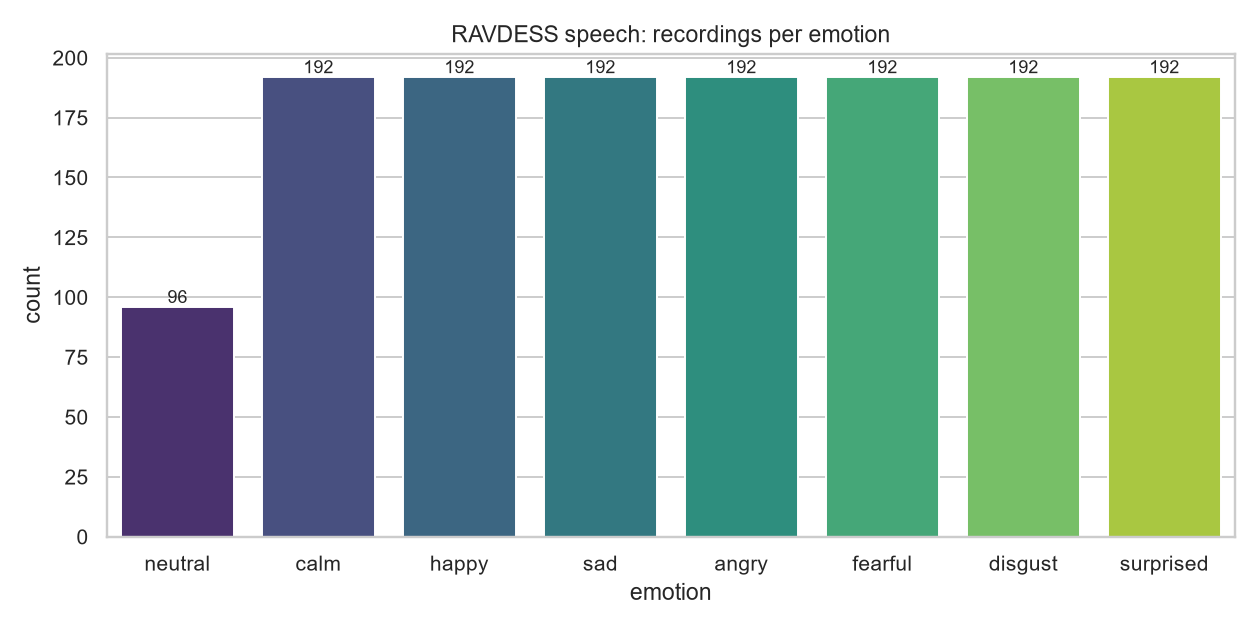

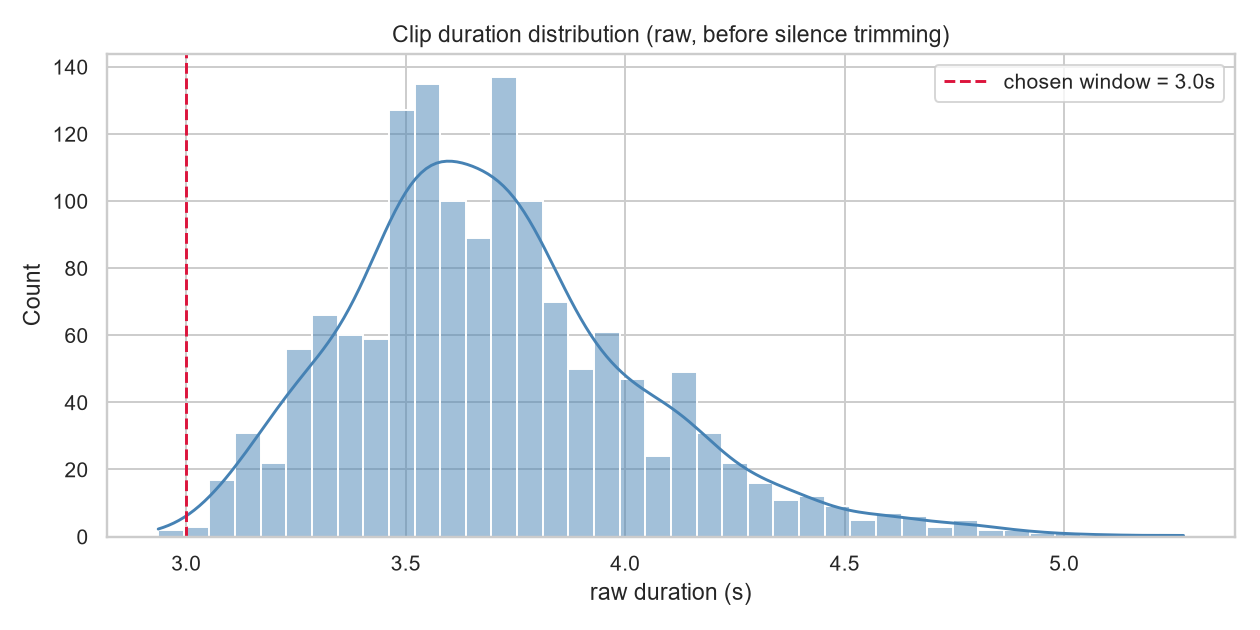

In [4]:
display(Image(str(FIG / "01_emotion_distribution.png")))
display(Image(str(FIG / "02_duration_distribution.png")))

## 2. Speaker-independent split

This is the methodological core of the project. A random file-level split
would put recordings of the same actor in both train and test, letting the
network recognise the **voice** instead of the **emotion**.

In [5]:
print("actors per split:", summary["split_actors"])
print("clips per split :", summary["split_files"])

groups = {s: set(g["actor"]) for s, g in manifest.groupby("split")}
assert not (groups["train"] & groups["val"])
assert not (groups["train"] & groups["test"])
assert not (groups["val"] & groups["test"])
print("\nverified: no actor appears in more than one split")

actors per split: {'test': [20, 21, 22, 23], 'train': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 24], 'val': [16, 17, 18, 19]}
clips per split : {'train': 960, 'val': 240, 'test': 240}

verified: no actor appears in more than one split


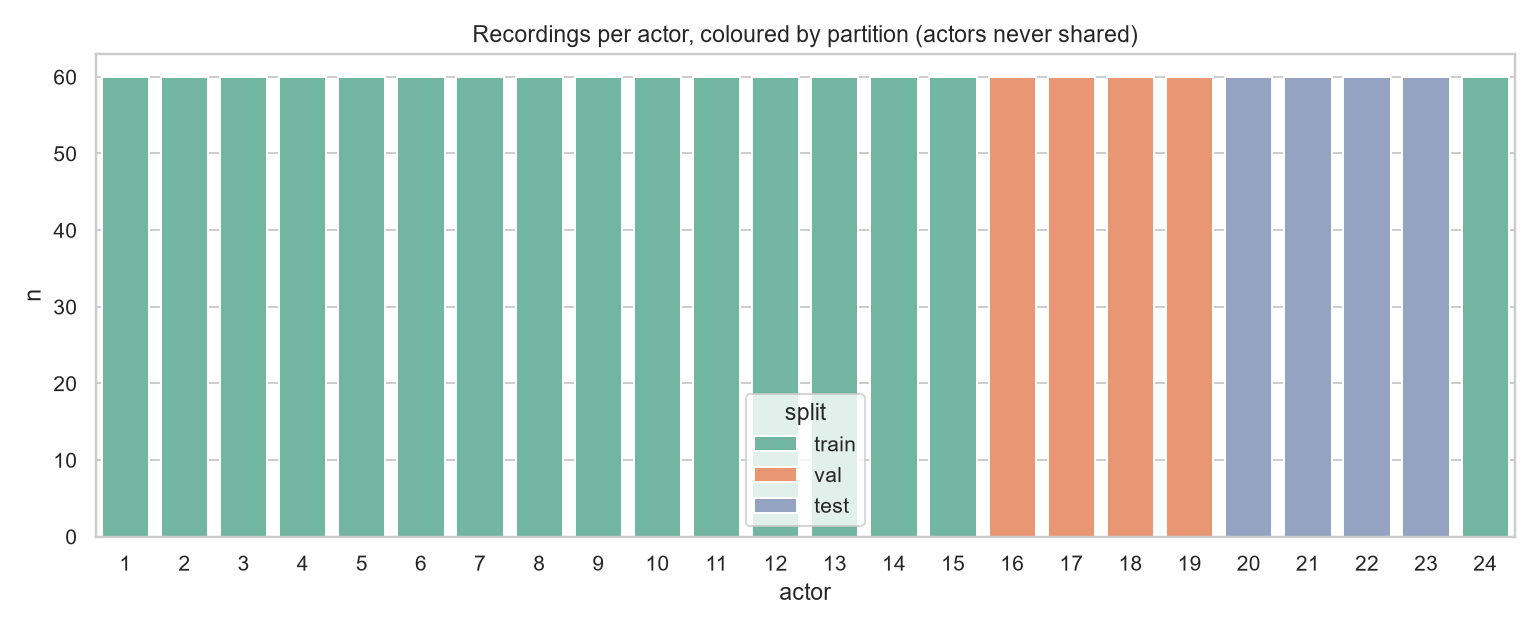

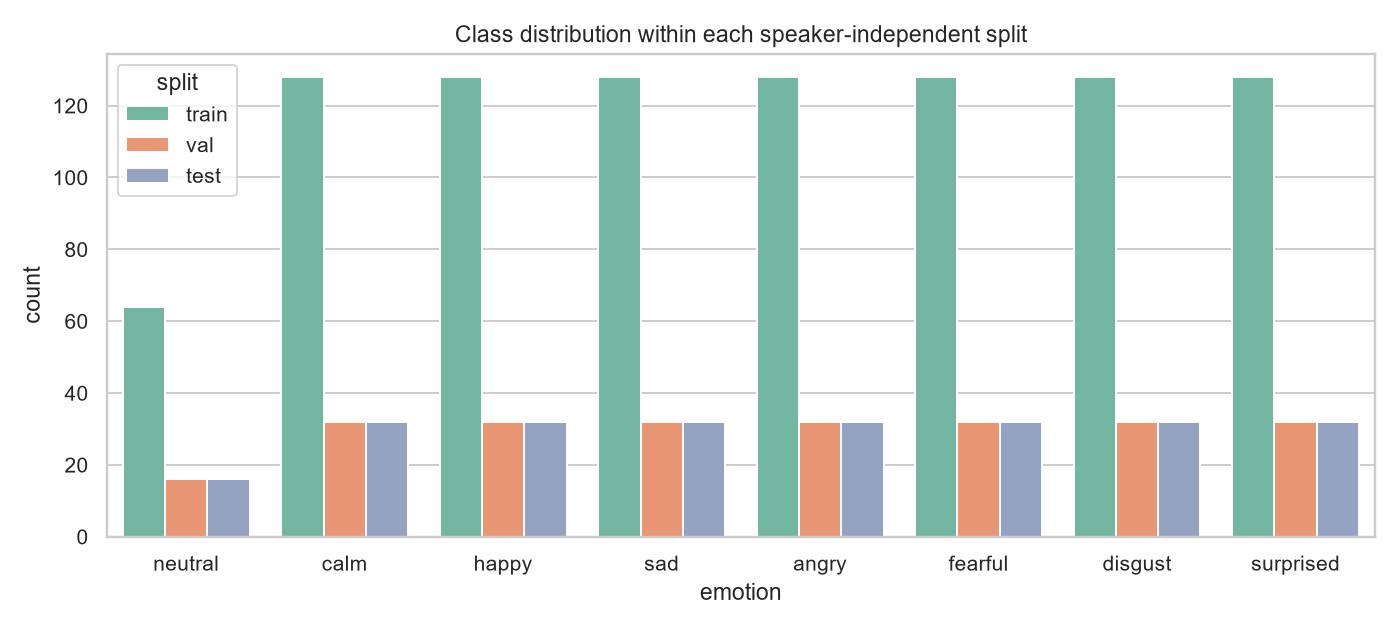

In [6]:
display(Image(str(FIG / "04_actor_distribution.png")))
display(Image(str(FIG / "03_split_distribution.png")))

## 3. Preprocessing and MFCC features

Identical chain for train / val / test / inference:
mono -> 16 kHz -> trim leading+trailing silence -> peak-normalise ->
centre crop or pad to exactly 3 s.

MFCCs describe the **spectral envelope** — vocal-tract shape and voice
quality — which is precisely what emotion alters (tense vs breathy phonation,
formant shifts, spectral tilt). The delta and delta-delta channels add how
those quantities change over time, capturing prosodic dynamics.

In [7]:
from audio_preprocessing import preprocess
from feature_extraction import features_from_file

row = manifest[(manifest.emotion == "angry") & (manifest.split == "train")].iloc[0]
y = preprocess(row["path"])
feats = features_from_file(row["path"])

print("file            :", row["filename"], "| emotion:", row["emotion"])
print("waveform samples:", y.shape, "->", len(y) / C.SAMPLE_RATE, "s at", C.SAMPLE_RATE, "Hz")
print("CNN view        :", feats["cnn"].shape, " (n_mfcc, frames, [mfcc, delta, delta2])")
print("sequence view   :", feats["seq"].shape, " (frames, n_mfcc*3)")
print("stats view      :", feats["stats"].shape, " (fixed-length descriptor)")

file            : 03-01-05-01-01-01-01.wav | emotion: angry
waveform samples: (48000,) -> 3.0 s at 16000 Hz
CNN view        : (40, 94, 3)  (n_mfcc, frames, [mfcc, delta, delta2])
sequence view   : (94, 120)  (frames, n_mfcc*3)
stats view      : (276,)  (fixed-length descriptor)


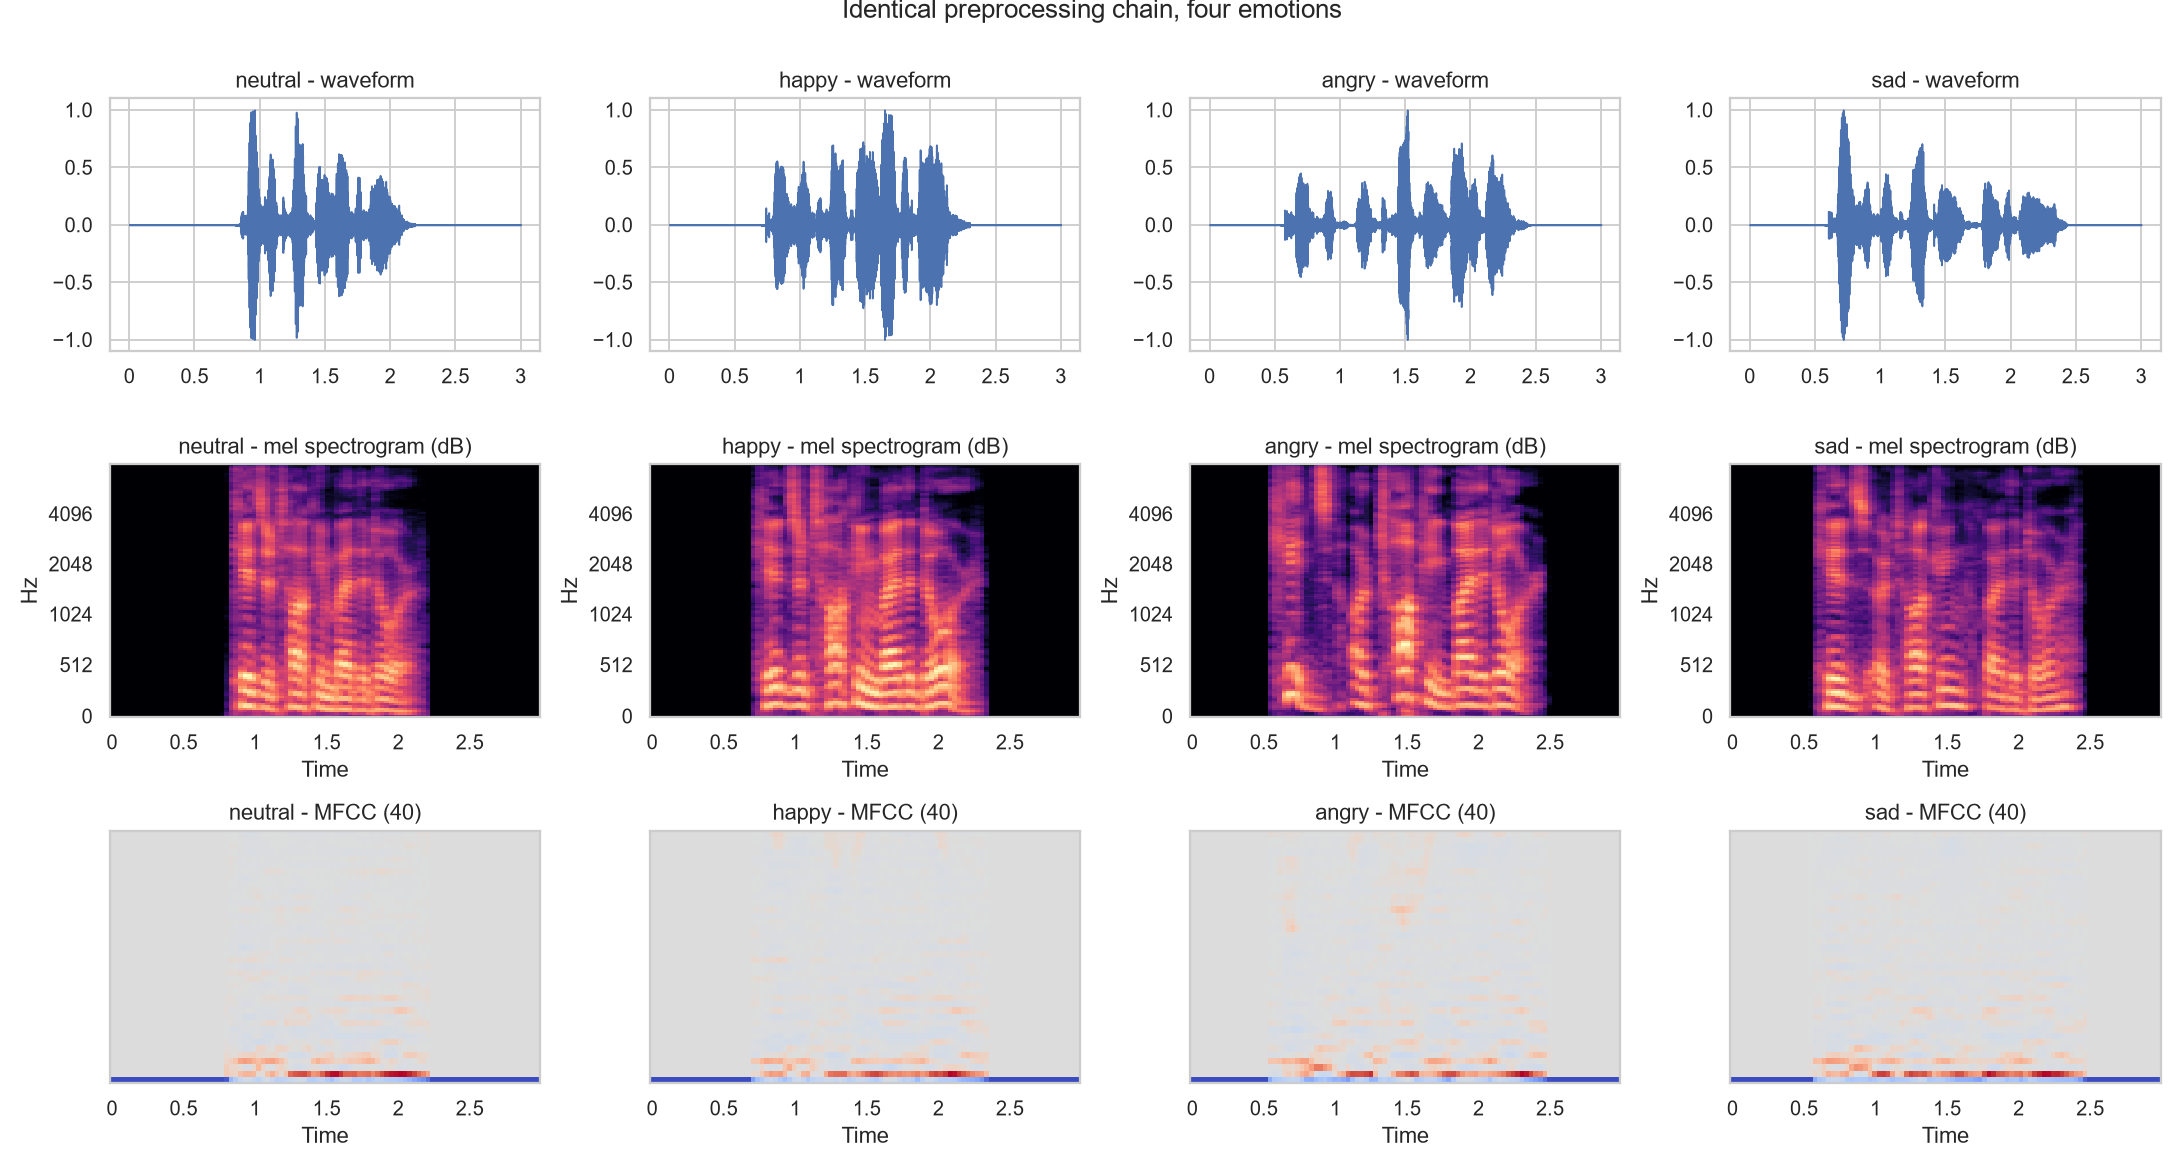

In [8]:
display(Image(str(FIG / "05_waveform_mel_mfcc.png")))

### Do simple descriptors already separate emotions?

Loudness and brightness separate high-arousal from low-arousal emotions, but
they do **not** separate emotions that share arousal (happy vs angry). That
overlap is what the deep models have to resolve — and, as the confusion
matrix later shows, it is exactly where they still fail.

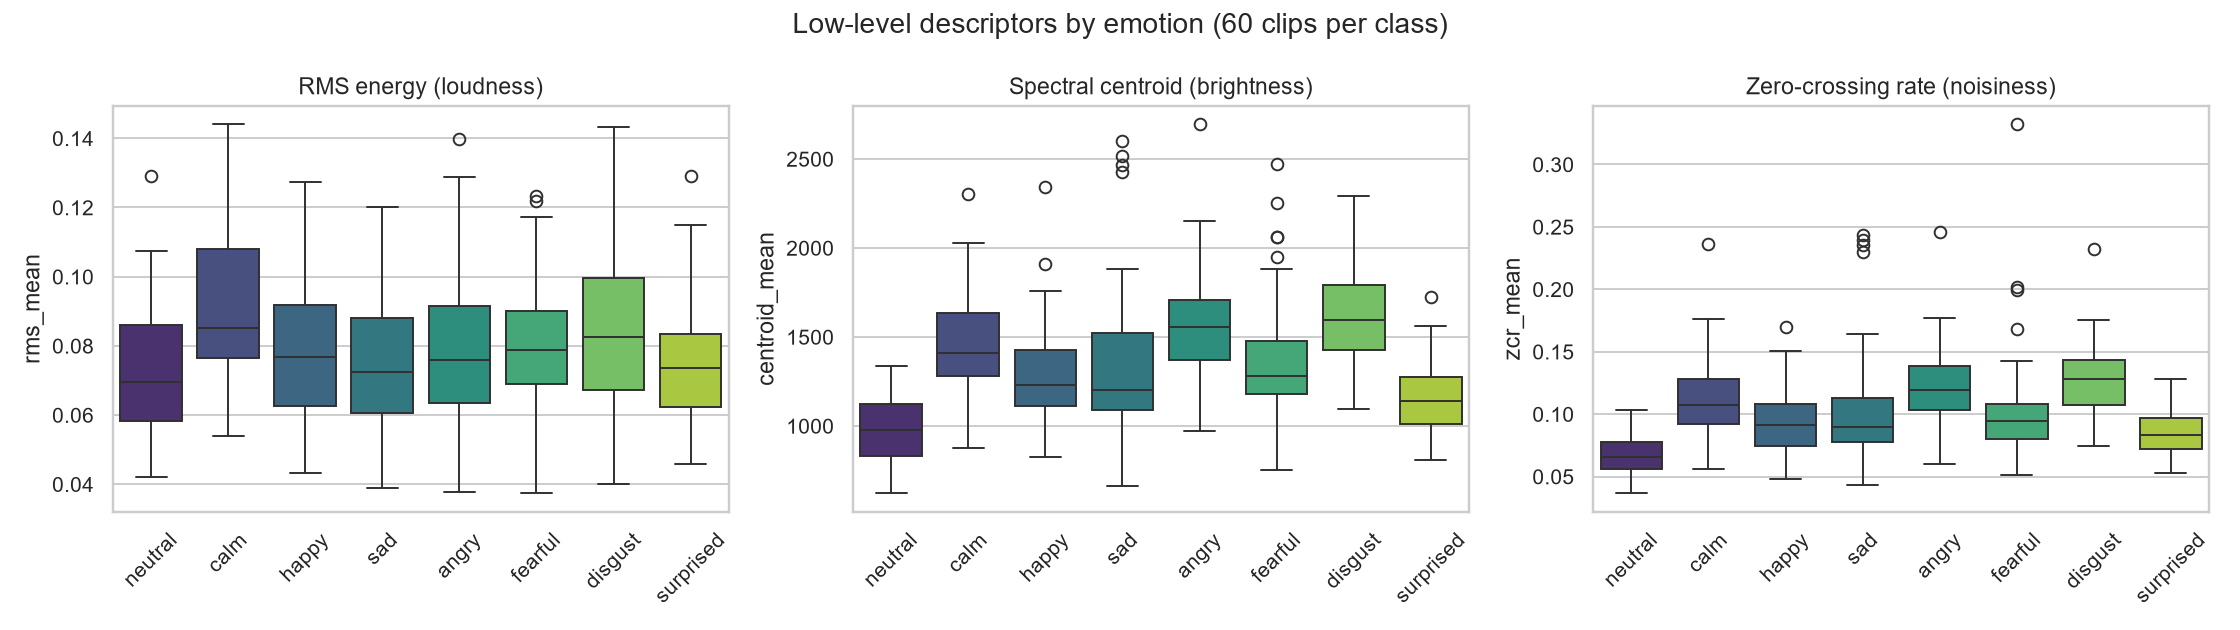

In [9]:
display(Image(str(FIG / "06_feature_comparison.png")))

## 4. Models

- **CNN** — learns local time-frequency patterns over the MFCC map.
- **BiLSTM** — carries state across 32 ms frames, modelling how prosody evolves.
- **CNN-LSTM** — convolutions compress each time slice, LSTM integrates the sequence.

All three are trained with Adam, early stopping on validation macro-F1,
learning-rate reduction on plateau, checkpointing and class weights.

In [10]:
from models import build_cnn
build_cnn(n_classes=8).summary()

Model: "CNN2D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mfcc_stack (InputLayer)         │ (None, 40, 94, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 40, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 40, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 40, 94, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 40, 94, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 40, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 20, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 20, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 20, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 20, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 47, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 47, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 20, 47, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 10, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 10, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 10, 23, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 10, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 10, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 10, 23, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 10, 23, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 306,344 (1.17 MB)

 Trainable params: 305,448 (1.17 MB)

 Non-trainable params: 896 (3.50 KB)

## 5. Model selection — validation only

The test set is not consulted for any decision here. Raw argmax over a
240-clip validation split rewards noise, so a bootstrap estimates the standard
error of macro-F1 and the **simplest model within one SE of the best** wins.

In [11]:
ranking = json.loads((MET / "validation_ranking.json").read_text())
pd.DataFrame([{"model": r["name"], "val_acc": round(r["val_accuracy"], 4),
               "val_macro_f1": round(r["val_macro_f1"], 4),
               "params": r["params"], "epochs": r["epochs_run"],
               "train_s": r["train_seconds"]} for r in ranking])

,model,val_acc,val_macro_f1,params,epochs,train_s
0,cnn_t2,0.6833,0.6609,1216840,48,2939.7
1,cnn_aug,0.6708,0.6502,306344,36,963.2
2,cnn_t1,0.6708,0.6502,306344,36,701.5
3,cnn_t3,0.6375,0.6233,75688,40,754.4
4,cnnlstm_aug,0.5958,0.5919,1054728,30,1262.0
5,lstm_aug,0.5292,0.5157,428104,32,583.3
6,cnn_noaug,0.2917,0.2254,306344,34,307.3


In [12]:
card = json.loads((ROOT / "models" / "final_model" / "model_card.json").read_text())
sel = card["selection_details"]
print("best raw score   :", sel["best_raw_model"], round(sel["best_raw_val_macro_f1"], 4))
print("bootstrap SE     :", round(sel["bootstrap_se"], 4))
print("within 1 SE      :", sel["models_within_1se"])
print("SELECTED         :", card["selected_model"], f"({card['params']:,} params)")
print("rule             :", sel["rule"])

best raw score   : cnn_t2 0.6609
bootstrap SE     : 0.0307
within 1 SE      : ['cnn_aug', 'cnn_t1', 'cnn_t2']
SELECTED         : cnn_aug (306,344 params)
rule             : one-standard-error rule on validation macro-F1; fewest parameters among models within 1 SE of the best


### Effect of augmentation

`cnn_noaug` and `cnn_aug` are the same architecture and the same settings; the
only difference is the 3x augmented training pool. The gap is large, and part
of it is not regularisation at all: with only ~30 gradient steps per epoch the
BatchNorm moving statistics never converge, so validation (which uses those
statistics) collapses while training looks fine.

In [13]:
for name in ["cnn_noaug", "cnn_aug"]:
    r = json.loads((ROOT / "models" / "cnn" / f"{name}_result.json").read_text())
    print(f"{name:12s} val_acc={r['val_accuracy']:.4f} "
          f"val_macro_f1={r['val_macro_f1']:.4f}")

cnn_noaug    val_acc=0.2917 val_macro_f1=0.2254
cnn_aug      val_acc=0.6708 val_macro_f1=0.6502


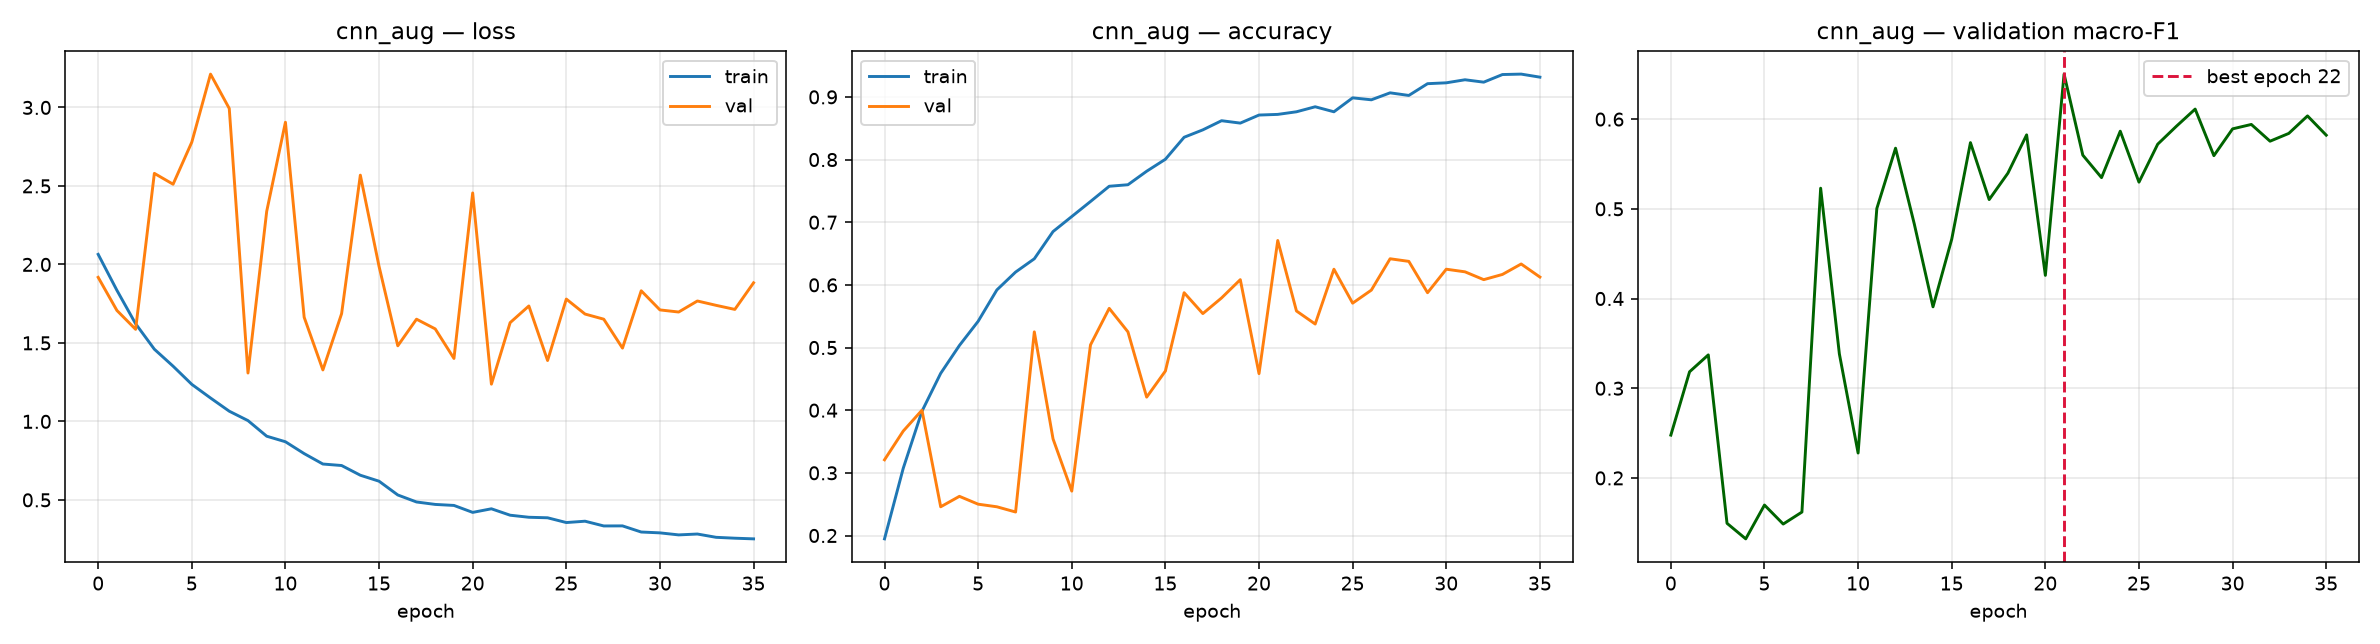

In [14]:
display(Image(str(FIG / "curves_cnn_aug.png")))

## 6. Test-set results — 4 unseen actors

Scored once, after every decision was made.

In [15]:
pd.read_csv(MET / "model_comparison.csv")

,Model,Accuracy,Precision(macro),Recall(macro),Macro F1,Weighted F1,ROC-AUC(ovr),Params,ms/clip
0,cnn_t2,0.6958,0.7199,0.7109,0.7007,0.6974,0.9521,1216840.0,9.367
1,cnn_aug,0.7000,0.6986,0.7031,0.6905,0.6894,0.9416,306344.0,2.534
2,cnn_t1,0.7000,0.6986,0.7031,0.6905,0.6894,0.9416,306344.0,5.519
3,cnn_t3,0.6333,0.6214,0.6367,0.6209,0.6246,0.9297,75688.0,2.288
4,cnnlstm_aug,0.5292,0.5322,0.5352,0.5158,0.5184,0.8562,1054728.0,9.023
5,baseline_logreg,0.4542,0.4623,0.4570,0.4514,0.4518,0.8509,NaN,0.000
6,lstm_aug,0.4250,0.4437,0.4180,0.4106,0.4142,0.8148,428104.0,6.610
7,baseline_svm_rbf,0.4167,0.4192,0.4062,0.4022,0.4118,0.8307,NaN,0.401
8,baseline_random_forest,0.4292,0.4063,0.4219,0.3927,0.4022,0.8343,NaN,0.363
9,cnn_noaug,0.3333,0.5470,0.3398,0.2913,0.2874,0.8463,306344.0,2.904


Accuracy alone would be misleading here. Macro-F1 averages per-class F1
without weighting by support, so a model that quietly abandons `neutral`
(half the support of every other class) is penalised. Precision = of the clips
called X, how many were X. Recall = of the clips that were X, how many were
found. F1 is their harmonic mean.

In [16]:
metrics = json.loads((MET / "test_metrics_all.json").read_text())
best = metrics[card["selected_model"]]
pd.DataFrame([{"emotion": k, "precision": round(v["precision"], 3),
               "recall": round(v["recall"], 3), "f1": round(v["f1-score"], 3),
               "support": int(v["support"])}
              for k, v in best["per_class"].items()]).sort_values("f1", ascending=False)

,emotion,precision,recall,f1,support
2,disgust,0.938,0.938,0.938,32
1,calm,0.737,0.875,0.800,32
7,surprised,0.651,0.875,0.747,32
6,sad,0.686,0.750,0.716,32
5,neutral,0.667,0.750,0.706,16
0,angry,0.789,0.469,0.588,32
3,fearful,0.576,0.594,0.585,32
4,happy,0.545,0.375,0.444,32


## 7. Confusion matrix

Read the right-hand panel row-wise: each row is a true emotion and shows where
its clips actually went.

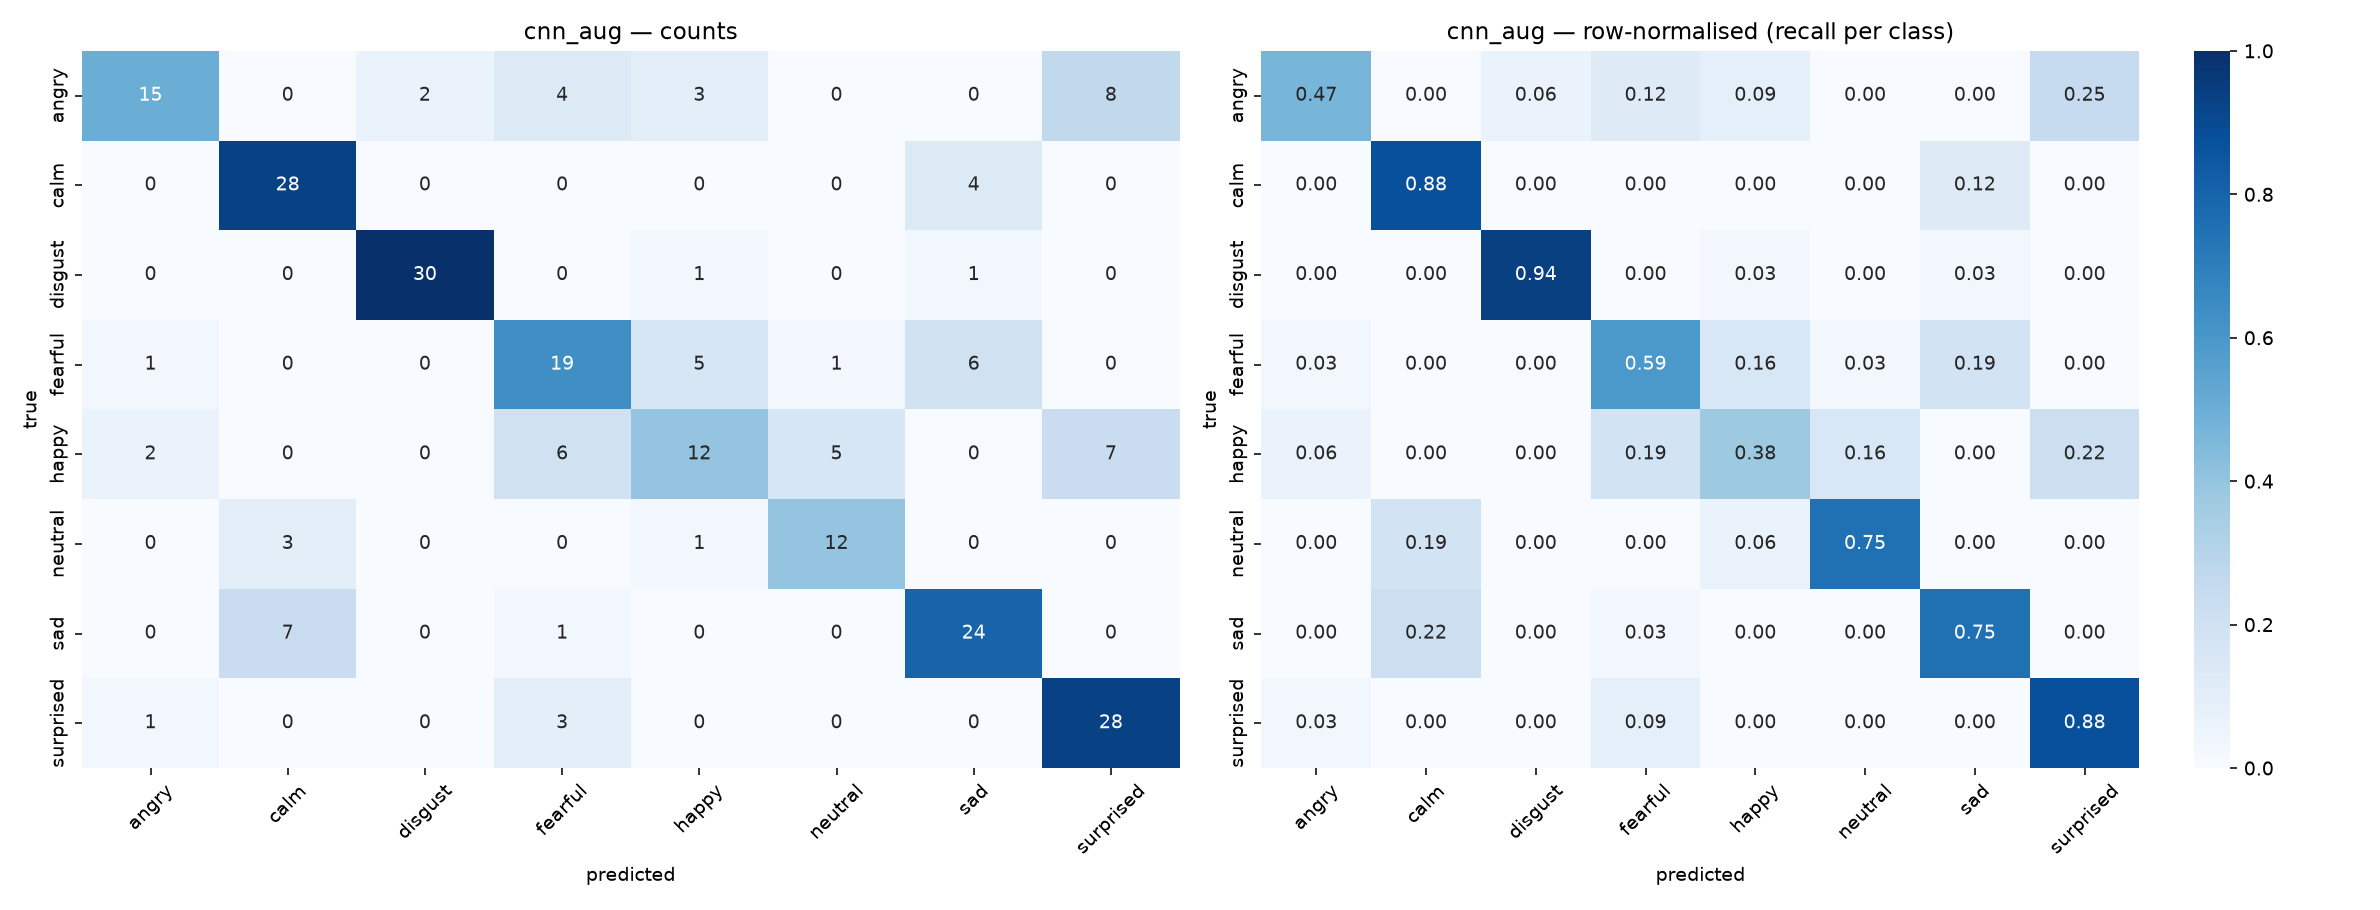

In [17]:
display(Image(str(FIG / f"cm_{card['selected_model']}.png")))

In [18]:
mis = pd.read_csv(ROOT / "outputs" / "predictions" /
                  f"misclassified_{card['selected_model']}.csv")
print(f"{len(mis)} misclassified of {summary['split_files']['test']} test clips")
mis.groupby(["true", "predicted"]).size().reset_index(name="count") \
   .sort_values("count", ascending=False).head(10)

72 misclassified of 240 test clips


,true,predicted,count
3,angry,surprised,8
14,happy,surprised,7
17,sad,calm,7
10,fearful,sad,6
12,happy,fearful,6
8,fearful,happy,5
13,happy,neutral,5
1,angry,fearful,4
4,calm,sad,4
15,neutral,calm,3


The errors are not random: they cluster by **arousal**. High-arousal
emotions (angry, happy, surprised, fearful) get confused with each other, and
low-arousal ones (sad, calm, neutral) with each other. Acoustically, arousal
is carried loudly by energy, pitch range and speaking rate — all easy to
measure. Valence (is this excitement or anger?) is far more subtle and is
largely what the model misses.

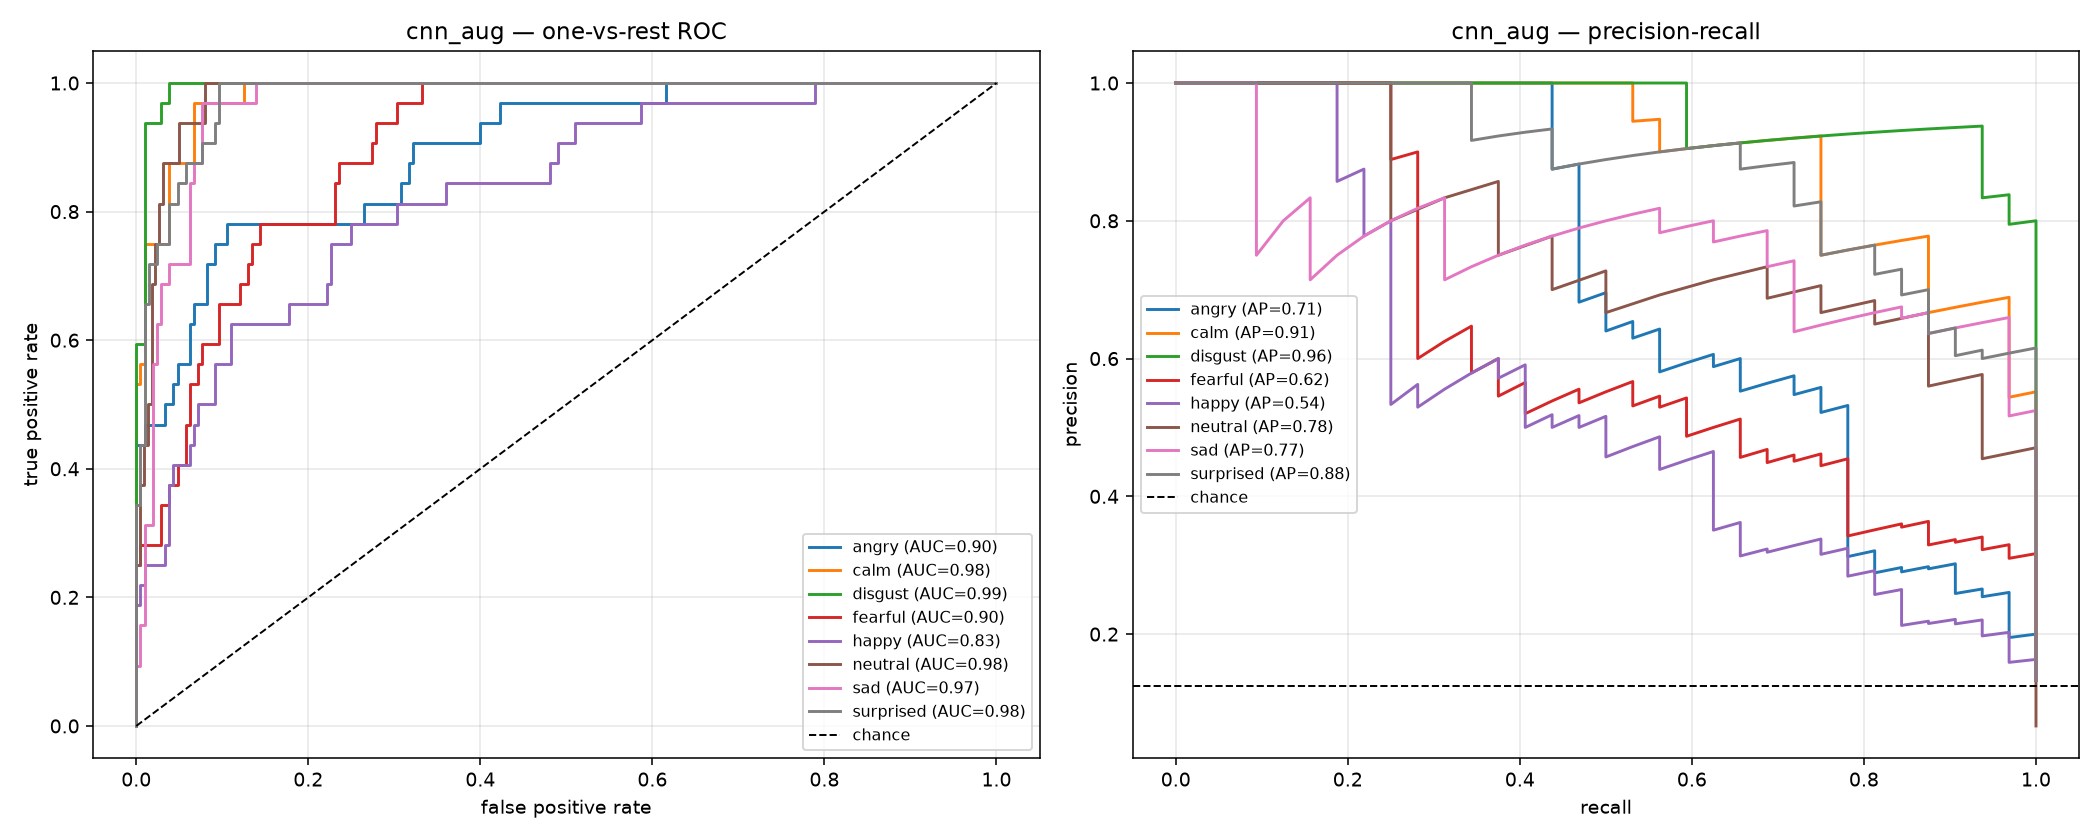

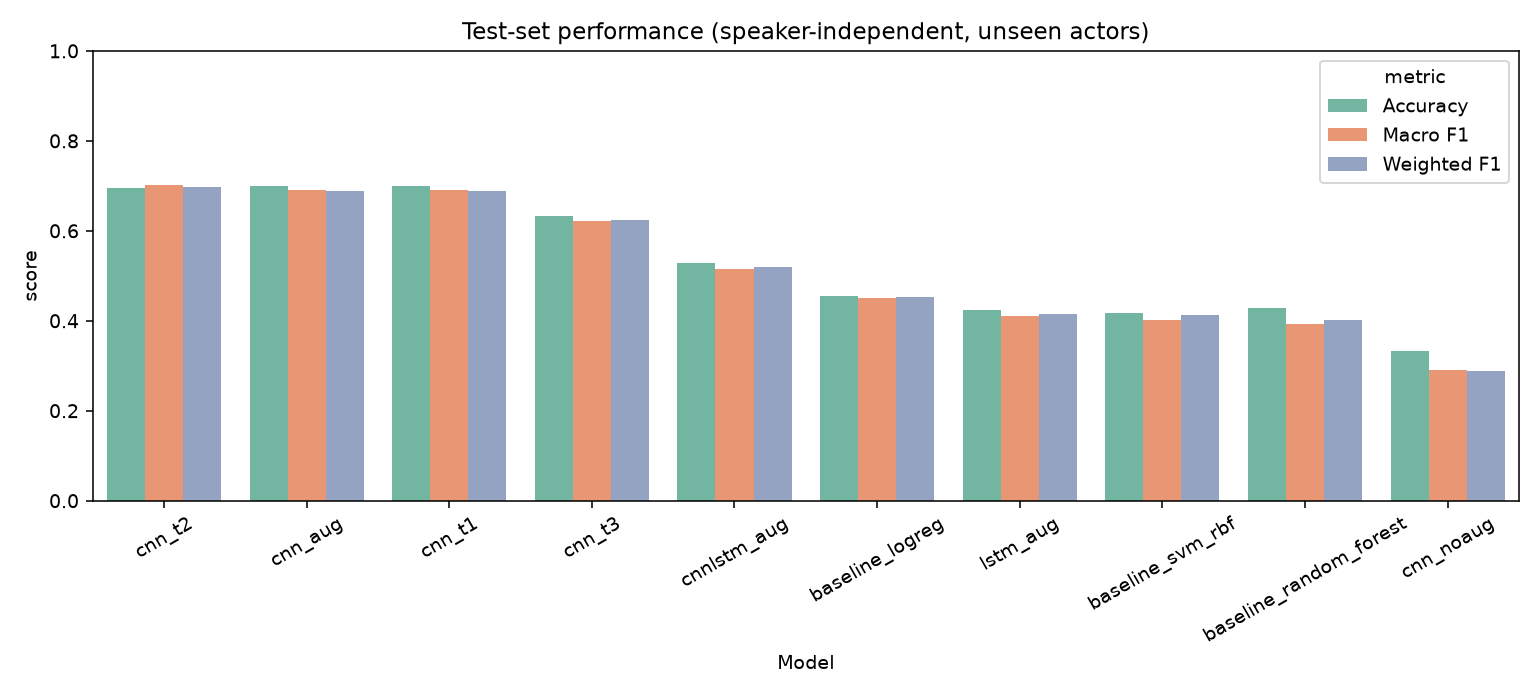

In [19]:
display(Image(str(FIG / f"roc_pr_{card['selected_model']}.png")))
display(Image(str(FIG / "10_model_comparison.png")))

## 8. Confidence handling

The softmax maximum is used as a confidence score. The threshold is not
invented — it is swept on **validation** data, trading coverage against
selective accuracy (accuracy among the clips the model accepts).

chosen threshold        : 0.82
coverage (val)          : 57.1%
selective accuracy (val): 81.0%


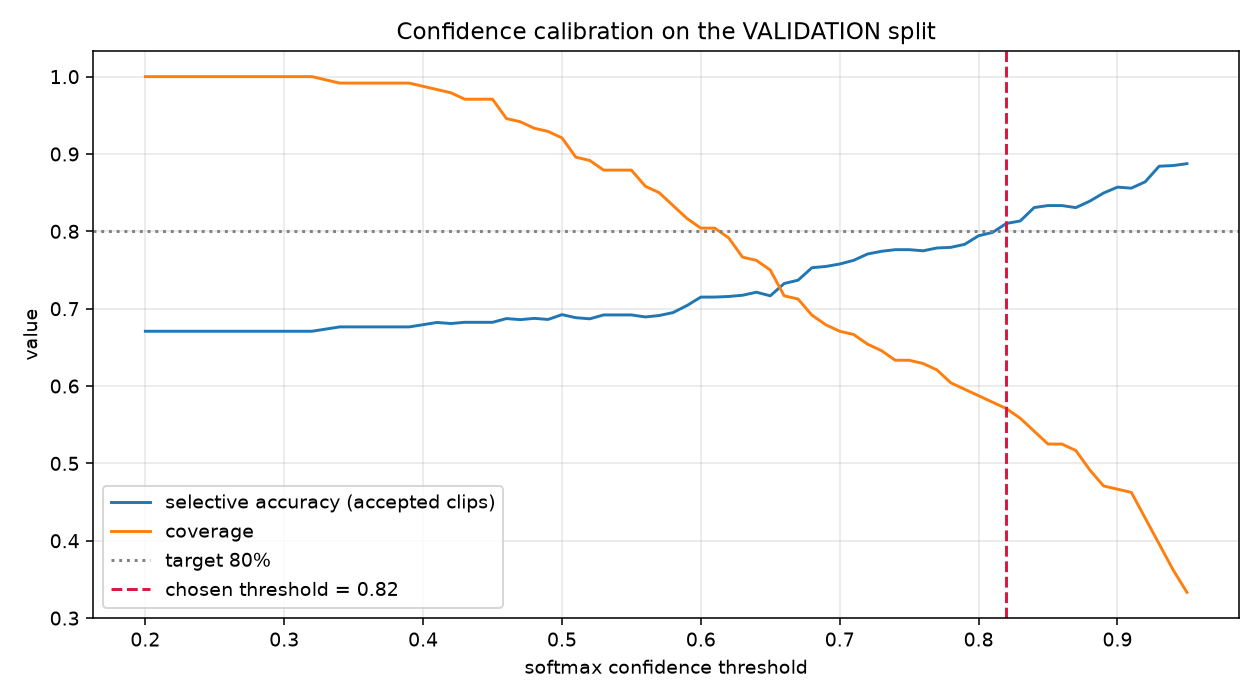

In [20]:
calib = json.loads((MET / "confidence_calibration.json").read_text())
print("chosen threshold        :", calib["threshold"])
print("coverage (val)          :", f"{calib['coverage_at_threshold']:.1%}")
print("selective accuracy (val):", f"{calib['selective_accuracy_at_threshold']:.1%}")
display(Image(str(FIG / "11_confidence_calibration.png")))

## 9. Reload the saved model and predict

The bundle in `models/final_model/` holds the network, the label encoder, the
normalisation statistics and the feature configuration. `EmotionRecognizer`
raises if the live feature code no longer matches the stored configuration.

In [21]:
from predict import EmotionRecognizer, format_result

rec = EmotionRecognizer()
print("architecture:", rec.card["architecture"], "| classes:", rec.classes)
print("threshold   :", rec.threshold)

architecture: cnn | classes: [np.str_('angry'), np.str_('calm'), np.str_('disgust'), np.str_('fearful'), np.str_('happy'), np.str_('neutral'), np.str_('sad'), np.str_('surprised')]
threshold   : 0.82


In [22]:
test_clip = manifest[manifest.split == "test"].sample(1, random_state=C.SEED).iloc[0]
print("true emotion:", test_clip["emotion"], "| actor:", test_clip["actor"],
      "(never seen in training)\n")
print(format_result(rec.predict(test_clip["path"])))

true emotion: sad | actor: 20 (never seen in training)



Audio              : 03-01-04-02-01-01-20.wav
Predicted Emotion  : SAD
Confidence         : 94.7%
Status             : confident

Emotion probabilities:
  sad         94.73%  ######################################
  calm         4.70%  ##
  neutral      0.28%  
  fearful      0.17%  
  happy        0.09%  
  disgust      0.02%  
  surprised    0.01%  
  angry        0.00%  


## 10. Dataset test performance vs degraded-channel performance

These are different questions and are kept apart.

In [23]:
unseen = json.loads((MET / "unseen_audio_summary.json").read_text())
sim = unseen["simulated_channel"]
print(f"clean test audio (240 clips)     : {unseen['test_accuracy_all']:.1%}")
print(f"  restricted to confident clips  : {unseen['test_accuracy_confident']:.1%}"
      f"  (coverage {unseen['confident_coverage']:.1%})")
print(f"simulated degraded channel       : {sim['n_correct']}/{sim['n']}"
      f" = {sim['n_correct'] / sim['n']:.1%}")

clean test audio (240 clips)     : 70.0%
  restricted to confident clips  : 77.8%  (coverage 63.7%)
simulated degraded channel       : 5/8 = 62.5%


The degraded files in `data/external/` are held-out test clips passed
through a telephone band or a reverberant far-field channel. They measure
robustness to an unseen **recording channel**, not generalisation to unseen
speakers — the test split already covers that. Accuracy drops, and usefully so
does confidence, so most degraded clips are flagged uncertain rather than
answered wrongly with conviction.

To test genuinely external audio, drop your own `.wav` files into
`data/external/` and re-run `src/test_unseen_audio.py`.

## 11. Limitations

- RAVDESS is **acted** emotion, two fixed sentences, studio-recorded.
- 16 training actors is few; per-actor test accuracy spans 0.617–0.783.
- Same-arousal emotion pairs remain hard for acoustic-only models.
- Channel mismatch degrades performance measurably.